# Mobile App Update Impact and Failure Detection — Review 1

**23CSE452 Business Analytics · Team 10 · Review 1: Data Analysis and Predictive Modelling**

| # | Name | Register number | Stage |
|---|---|---|---|
| 1 | Aditya Monish Kumar K | CB.SC.U4CSE23103 | Data collection and preprocessing |
| 2 | Regella Krishna Saketh | CB.SC.U4CSE23649 | Exploratory data analysis (with Akshay KS) |
| 3 | Akshay KS | CB.SC.U4CSE23104 | Exploratory data analysis (with Regella Krishna Saketh) |
| 4 | Harshini Vennela | CB.SC.U4CSE23455 | Feature engineering and predictive model (with Kanishka D) |
| 5 | Kanishka D | CB.SC.U4CSE23155 | Feature engineering and predictive model (with Harshini Vennela) |

This notebook re-runs the Review 1 analysis end to end on our own Play Store data and shows the evidence for each rubric component:

1. Problem statement and dataset description
2. Data cleaning and preprocessing
3. Exploratory data analysis and visualization
4. Feature engineering and dimensionality reduction
5. Predictive model development
6. Model evaluation and result interpretation

The production scripts in `scripts/` do the same steps (and write every chart and table); this notebook recomputes the key numbers so they can be checked. Full write-ups: `DATA_SOURCES.md`, `EDA.md`, `MODEL_EVALUATION.md`, `REPORT.md`.

*Runtime: about 5–6 minutes on a 20-core machine (the model training is the slow part).*

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "scripts"))
from apps import APPS, APP_NAMES, DOMAINS, APP_DOMAIN, APP_COLORS
from data_io import read_stage, read_app

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Repository:", REPO)

Repository: /home/Adithya/Desktop/Sem 7/BA/BAProject/topic1_app_review_dataset


## 1. Problem statement and business objective

Swiggy, Zomato, Flipkart, Amazon, Paytm, PhonePe and similar apps receive hundreds of Play Store reviews **every day**, and the busiest more than a thousand. Many report real problems (failed payments, late deliveries, refunds that never arrive, crashes after an update). No team can read them all, so problems — including bad app updates — are noticed late and it is hard to say which problem matters most.

**Research gap.** Published work (Pagano & Maalej 2013; Chen et al. 2014, AR-Miner; Guzman & Maalej 2014; Maalej & Nabil 2015; Hutto & Gilbert 2014, VADER) mostly treats reviews as one fixed set with generic labels ("bug", "feature request") and rarely checks how the collection method biases results.

**Our approach.** Collect every review ourselves, tag domain-specific issues, score sentiment, explore the data with explicit checks for collection artefacts, compare app versions, and train a classifier that flags problem reviews.

**Business objective.** Show which problems hurt users most in each app and domain, whether a new app version made things worse, and automatically surface the reviews that need attention.

**Key terms**
* **Problem review** = a review rated 1–2★ (`is_problematic = 1`). The rating is the user's own judgement, so the classifier finds dissatisfied users; the 9 issue tags name the failure when the text mentions one. Many problem reviews are just "bad" or "worst app", and some are mis-ratings (the most common untagged 1–2★ text is "good").
* **Update impact** = how ratings and complaints change between app versions. Review 1 compares each version with its app's average (Section 4, EDA charts 12–13); Review 2 will compare ratings just before and after each new version first appears, which the continuous daily data makes possible.

## 2. Dataset description

* **Source:** Google Play Store, via the `google-play-scraper` package (calls the Play Store review endpoint; no login). No Kaggle/UCI/GitHub dataset was used.
* **Method:** `scripts/01_scrape_reviews.py` requests reviews with `Sort.NEWEST`, 200 per page, and follows the continuation token backwards in time until a whole page is older than **1 April 2026**, keeping reviews up to **20 September 2026**. So we have **every** English/India review of each app in the window, not a sample.
* **Apps:** 11 apps in 3 domains (list below; single source of truth `scripts/apps.py`).
* **Window:** 1 April – 20 September 2026, identical for every app. Raw data: one gzipped CSV per app in `data/raw/`.

In [2]:
meta = pd.read_csv(REPO / "data" / "app_metadata.csv")
meta["package"] = meta["app_name"].map({a["name"]: a["package"] for a in APPS.values()})
meta[["domain", "app_name", "package", "category", "installs", "current_score"]].sort_values(["domain", "app_name"]).reset_index(drop=True)

,domain,app_name,package,category,installs,current_score
0,Food & Grocery,Blinkit,com.grofers.customerapp,Food & Drink,"100,000,000+",4.575060
1,Food & Grocery,Domino's,com.Dominos,Food & Drink,"100,000,000+",4.538507
2,Food & Grocery,Swiggy,in.swiggy.android,Food & Drink,"100,000,000+",4.496276
3,Food & Grocery,Zomato,com.application.zomato,Food & Drink,"100,000,000+",4.560704
4,Payments,Google Pay,com.google.android.apps.nbu.paisa.user,Finance,"1,000,000,000+",4.336493
5,Payments,Paytm,net.one97.paytm,Finance,"500,000,000+",4.669618
6,Payments,PhonePe,com.phonepe.app,Finance,"1,000,000,000+",4.431528
7,Shopping,Amazon,in.amazon.mShop.android.shopping,Shopping,"500,000,000+",4.182552
8,Shopping,Flipkart,com.flipkart.android,Shopping,"1,000,000,000+",4.341977
9,Shopping,Meesho,com.meesho.supply,Shopping,"500,000,000+",4.384886


In [3]:
t0 = time.time()
raw = read_stage("raw", parse_dates=["review_date"])
print(f"Raw dataset: {raw.shape[0]:,} rows x {raw.shape[1]} columns  (loaded in {time.time()-t0:.0f}s)")
print("Review dates:", raw["review_date"].min(), "->", raw["review_date"].max())
raw.dtypes.to_frame("dtype").T

Raw dataset: 1,202,729 rows x 9 columns  (loaded in 2s)
Review dates: 2026-04-01 00:01:02 -> 2026-09-20 23:59:21


,app_id,app_name,domain,review_id,score,content,thumbs_up,app_version,review_date
dtype,object,object,object,object,int64,object,int64,object,datetime64[ns]


In [4]:
per_app = raw.groupby(["domain", "app_name"]).agg(raw_reviews=("review_id", "size"),
                                                  first=("review_date", "min"), last=("review_date", "max"))
per_app.sort_values("raw_reviews", ascending=False)

raw_reviews               first                last
domain         app_name                                                       
Shopping       Flipkart         288063 2026-04-01 00:01:02 2026-09-20 23:58:55
Food & Grocery Blinkit          237716 2026-04-01 00:02:31 2026-09-20 23:57:33
               Zomato           159399 2026-04-01 00:03:23 2026-09-20 23:56:29
Shopping       Meesho           107744 2026-04-01 00:03:52 2026-09-20 23:51:42
Payments       PhonePe           94101 2026-04-01 00:01:19 2026-09-20 23:47:12
Shopping       Myntra            87160 2026-04-01 00:08:48 2026-09-20 23:59:21
Food & Grocery Swiggy            78562 2026-04-01 00:03:27 2026-09-20 23:55:59
Payments       Paytm             47940 2026-04-01 00:19:39 2026-09-20 23:59:00
Food & Grocery Domino's          46298 2026-04-01 00:03:35 2026-09-20 23:56:00
Shopping       Amazon            34035 2026-04-01 00:06:19 2026-09-20 23:54:43
Payments       Google Pay        21711 2026-04-01 00:06:10 2026-09-20 23:47:43

A small sample of the raw data:

In [5]:
raw.sample(6, random_state=7)[["app_name", "score", "content", "thumbs_up", "app_version", "review_date"]]

,app_name,score,content,thumbs_up,app_version,review_date
127382,Zomato,5,easy enterface,0,19.7.7,2026-07-13 20:20:01
883300,Flipkart,5,super,0,9.1,2026-04-08 15:28:00
180420,Zomato,5,Zomoto restaurant is very good and delevery boy is a very faster,0,19.6.3,2026-05-21 14:19:19
356508,Blinkit,5,good work,0,18.7.0,2026-06-29 09:22:00
962313,Meesho,1,not fast delivery,1,28.7,2026-08-02 16:52:16
614998,Flipkart,5,nice,0,9.15,2026-09-17 07:15:42


**Key variables.** `app_name` / `domain` (category), `score` (1–5 stars), `content` (text), `thumbs_up` (helpful votes), `app_version` (reviewer's installed version), `review_date`.

**Prediction target.** `is_problematic = 1` if `score <= 2`, else 0 (created when the tagged data is loaded at the end of Section 3).

## 3. Data cleaning and preprocessing

Same rules as `scripts/02_clean_reviews.py`, applied here step by step:

1. Remove duplicate `review_id`s.
2. Remove empty or very short reviews (fewer than 3 characters after stripping).
3. Remove reviews with no letters at all (only emojis or punctuation).
4. Remove non-English reviews: fewer than 85% of the **letters** are basic Latin (a–z). Emojis, digits and punctuation are ignored, so an English review such as "good 👍" is kept.
5. Derive `month` and `review_length` (words).

In [6]:
print("Missing values in the raw data:")
print(raw.isna().sum()[lambda s: s > 0])

Missing values in the raw data:


content             3
app_version    159239
dtype: int64


In [7]:
def latin_letter_ratio(s):
    letters = [c for c in s if c.isalpha()]
    return sum(c.isascii() for c in letters) / len(letters) if letters else 0.0

df = raw.copy()
df["content"] = df["content"].fillna("").astype(str)
steps = [("Raw scraped data", len(df))]

df = df.drop_duplicates(subset="review_id")
steps.append(("Duplicate review_id removed", len(df)))

df = df[df["content"].str.strip().str.len() >= 3]
steps.append(("Empty / < 3 characters removed", len(df)))

df = df[df["content"].map(lambda s: any(c.isalpha() for c in s))]
steps.append(("No letters (emoji/punctuation) removed", len(df)))

df = df[df["content"].map(latin_letter_ratio) >= 0.85]
steps.append(("Non-English (< 85% Latin letters) removed", len(df)))

df["month"] = df["review_date"].dt.to_period("M").astype(str)
df["review_length"] = df["content"].str.split().str.len()

before_after = pd.DataFrame(steps, columns=["step", "rows"])
before_after["removed"] = (-before_after["rows"].diff()).fillna(0).astype(int)
print(f"Columns: {raw.shape[1]} raw -> {df.shape[1]} after cleaning")
before_after

Columns: 9 raw -> 11 after cleaning


,step,rows,removed
0,Raw scraped data,1202729,0
1,Duplicate review_id removed,1202729,0
2,Empty / < 3 characters removed,1155196,47533
3,No letters (emoji/punctuation) removed,1147776,7420
4,Non-English (< 85% Latin letters) removed,1137987,9789


Examples of removed reviews (too short, no letters, non-English):

In [8]:
removed = raw[~raw["review_id"].isin(df["review_id"])]
removed.sample(8, random_state=3)[["app_name", "score", "content"]]

,app_name,score,content
471022,Blinkit,5,👍👍
374441,Blinkit,5,😎
808375,Flipkart,5,❤️❤️❤️
805458,Flipkart,5,❤️❤️❤️❤️❤️❤️
1099338,PhonePe,5,ok
73642,Swiggy,5,ബെസ്റ്റ് കസ്റ്റമർ സർവീസ്
826480,Flipkart,5,ok
750331,Flipkart,5,filpkart से शॉपिंग करना ईजी व सुरक्षित है


**Check:** the cleaned files written by the script (`data/clean/`) have exactly the same rows.

In [9]:
clean_file_ids = read_stage("clean", columns=["review_id"])["review_id"]
assert len(clean_file_ids) == len(df) and set(clean_file_ids) == set(df["review_id"])
print(f"OK: data/clean/*.csv.gz has the same {len(df):,} reviews")
del raw, removed, clean_file_ids

OK: data/clean/*.csv.gz has the same 1,137,987 reviews


**Missing values after cleaning.** Only `app_version` is missing. We keep those rows: version is not a model feature and the text is still valid.

In [10]:
miss = df.isna().sum()
miss[miss > 0].to_frame("missing").assign(pct=lambda t: (t["missing"] / len(df) * 100).round(2))

,missing,pct
app_version,152017,13.36


**Outliers (Tukey 1.5 × IQR).** We keep all of them: they are real reviews, not errors. We handle them with medians, `log1p` and rank-based statistics instead of deleting the most-seen reviews.

In [11]:
def iqr(x):
    q1, q3 = x.quantile([.25, .75]); hi = q3 + 1.5 * (q3 - q1)
    return pd.Series({"median": x.median(), "upper_fence": hi, "n_above": int((x > hi).sum()),
                      "pct_above": round((x > hi).mean() * 100, 2), "max": x.max()})
pd.DataFrame({c: iqr(df[c]) for c in ["thumbs_up", "review_length"]}).T

,median,upper_fence,n_above,pct_above,max
thumbs_up,0.0,0.0,72945.0,6.41,11165.0
review_length,2.0,11.0,167193.0,14.69,167.0


**Encoding and scaling** (used in Section 5): review text → TF-IDF; the 9 issue categories are 0/1 columns; the 15 structural features are scaled with `StandardScaler`.

The issue tags and VADER sentiment scores are added by `scripts/03_tag_issues.py` and `scripts/04_sentiment_analysis.py`. We load that enriched dataset for the rest of the analysis.

In [12]:
del df
tagged = read_stage("tagged", parse_dates=["review_date"])
tagged["is_problematic"] = (tagged["score"] <= 2).astype(int)
print(f"Tagged dataset: {tagged.shape[0]:,} rows x {tagged.shape[1] - 1} columns (+ target)")
tagged[["app_name", "score", "content", "review_length", "primary_issue", "sentiment_compound", "sentiment_label"]].sample(5, random_state=11)

Tagged dataset: 1,137,987 rows x 29 columns (+ target)


,app_name,score,content,review_length,primary_issue,sentiment_compound,sentiment_label
847314,Flipkart,1,worst experience for ever i ordered one item on delivery day i got an message due to unexpected issue the ...,36,cancellation_return,-0.7906,Negative
238292,Blinkit,5,very useful,2,none,0.4927,Positive
933060,Meesho,5,excellent meesho super discount meesho I love me song,9,none,0.9153,Positive
1060648,PhonePe,5,Very Nice 💯,3,none,0.4754,Positive
320707,Blinkit,4,good,1,none,0.4404,Positive


## 4. Exploratory data analysis and visualization

`scripts/05_eda.py` produces 15 charts (`data/charts/eda/`) and stores every number in `data/eda_summary.json`. Here we recompute the main ones.

### 4.1 Rating mix by app

In [13]:
mix = (pd.crosstab(tagged["app_name"], tagged["score"], normalize="index") * 100).loc[APP_NAMES]
mix["% 1-2 stars"] = mix[1] + mix[2]
mix = mix.round(1)
mix["mean rating"] = tagged.groupby("app_name")["score"].mean().round(2)
mix["public rating"] = meta.set_index("app_name")["current_score"].round(2)
print(f"All apps: {tagged['score'].eq(5).mean()*100:.1f}% 5-star, {tagged['score'].eq(1).mean()*100:.1f}% 1-star, "
      f"median review length {tagged['review_length'].median():.0f} words")
mix.sort_values("% 1-2 stars", ascending=False)

All apps: 66.5% 5-star, 17.3% 1-star, median review length 2 words


score,1,2,3,4,5,% 1-2 stars,mean rating,public rating
app_name,,,,,,,,
Amazon,50.9,3.5,3.2,5.9,36.6,54.4,2.74,4.18
Swiggy,32.6,2.5,4.1,8.9,52.0,35.0,3.45,4.50
Domino's,21.0,2.6,4.7,9.6,62.1,23.6,3.89,4.54
Google Pay,19.8,3.4,4.4,8.5,64.0,23.2,3.93,4.34
Blinkit,16.5,2.5,4.3,10.7,66.0,19.0,4.07,4.58
Zomato,16.7,2.1,4.3,11.8,65.1,18.8,4.06,4.56
Flipkart,15.7,2.6,5.5,11.8,64.4,18.3,4.07,4.34
Meesho,16.3,1.2,1.7,5.4,75.3,17.6,4.22,4.38
Paytm,13.1,1.6,2.4,6.8,76.1,14.6,4.31,4.67


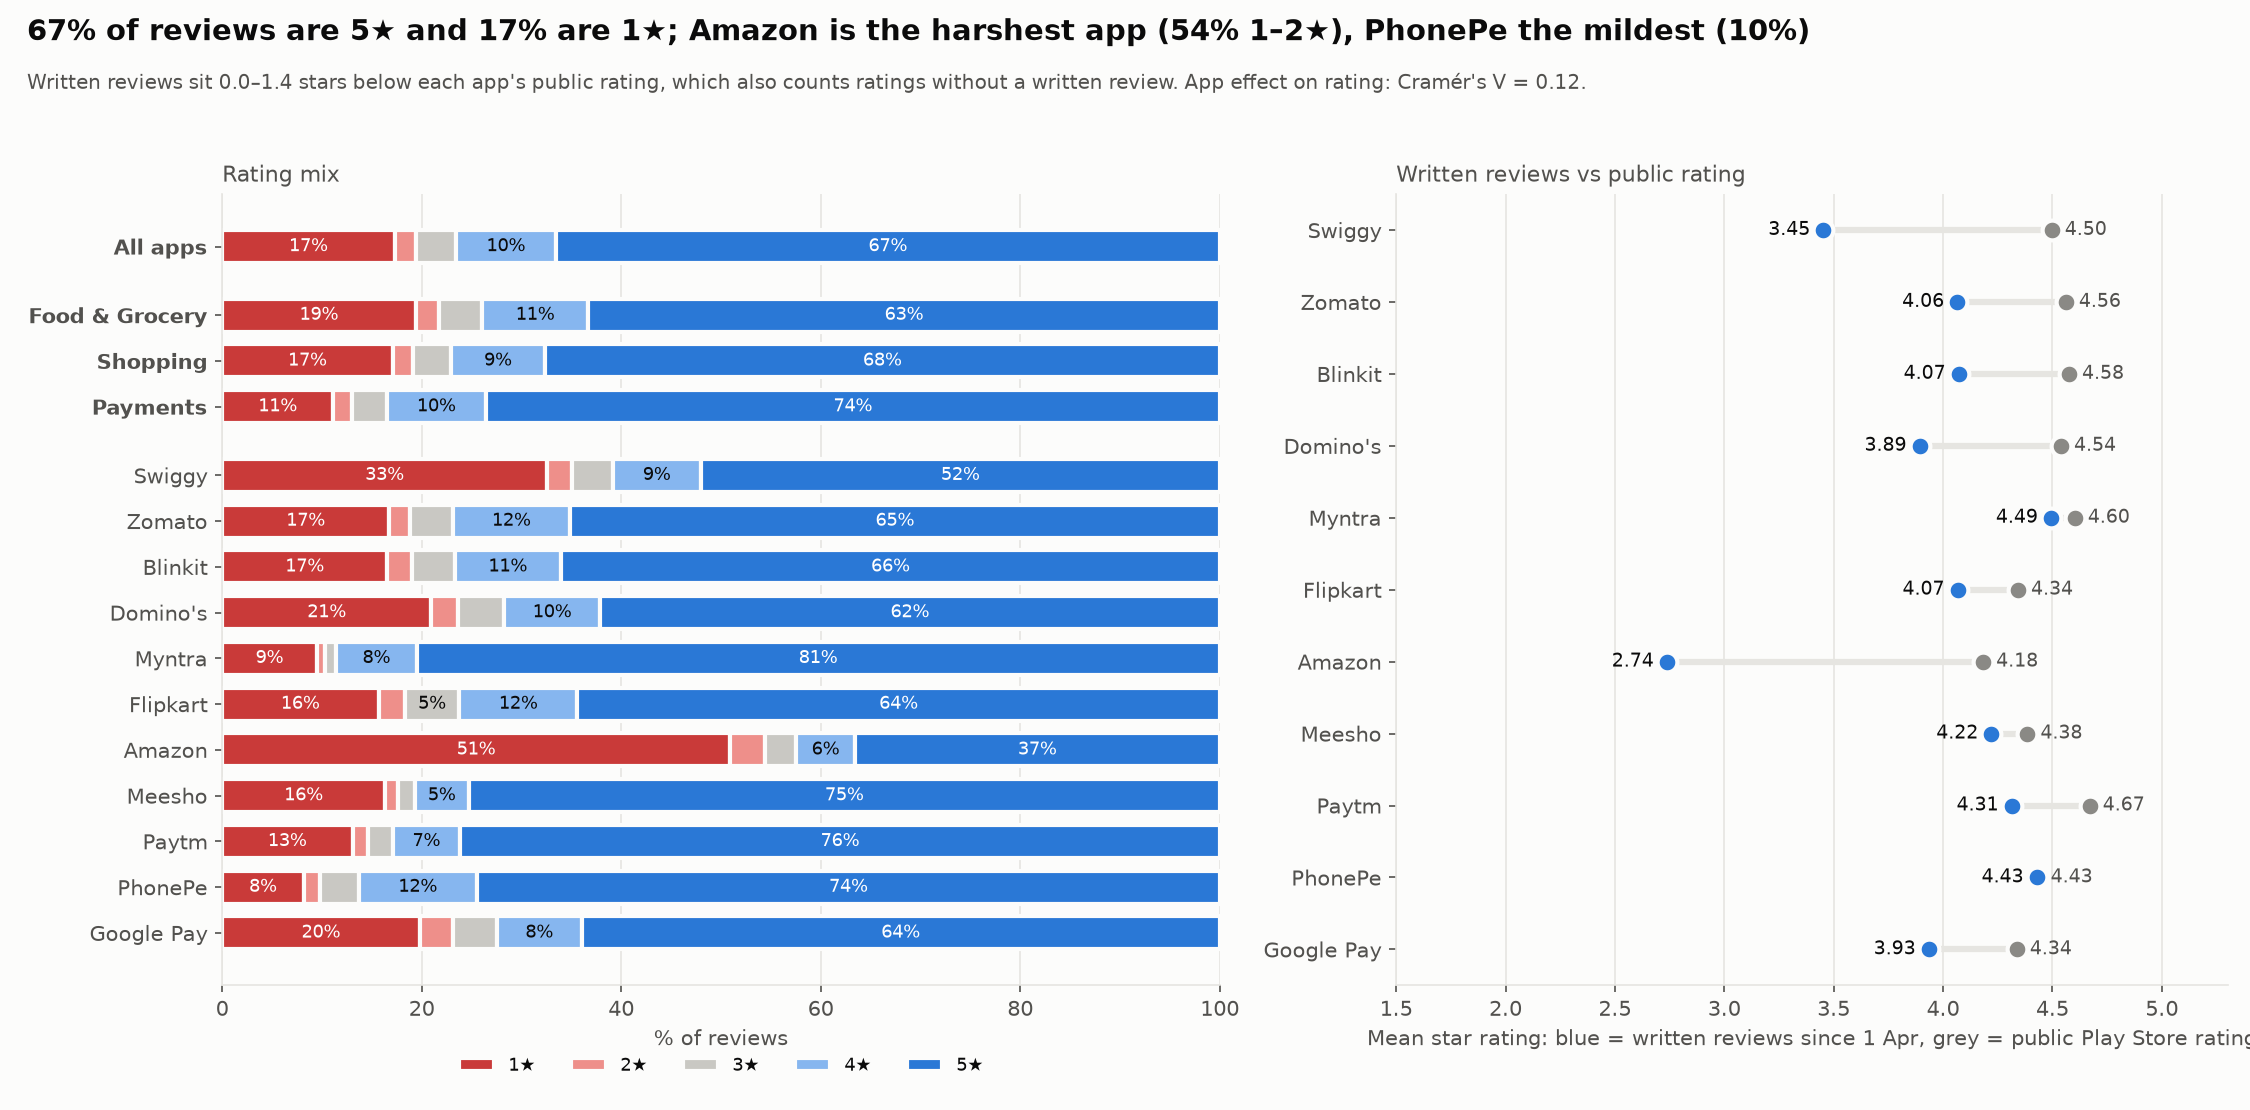

In [14]:
display(Image(REPO / "data/charts/eda/eda_02_ratings_vs_public.png", width=950))

**Finding 1.** Amazon (54% of reviews rated 1–2★) and Swiggy (35%) are far harsher than every other app (10–24%). Written reviews also sit below each app's public rating, which includes ratings without text. **Business meaning:** these two apps have a real, lasting service problem; compare apps with each other rather than quoting absolute satisfaction.

### 4.2 Issues by app and domain

In [15]:
ISSUES = ["crash_bugs_stability", "payment_refund", "delivery_delay", "order_quality_fulfillment", "cancellation_return",
          "customer_support", "account_login_otp", "pricing_charges_fraud", "ui_ux_update"]
prev = (tagged.groupby("app_name")[[f"issue_{i}" for i in ISSUES]].mean() * 100).loc[APP_NAMES].T.round(1)
prev.index = [i.replace("issue_", "") for i in prev.index]
prev

app_name,Swiggy,Zomato,Blinkit,Domino's,Myntra,Flipkart,Amazon,Meesho,Paytm,PhonePe,Google Pay
crash_bugs_stability,0.6,0.2,0.3,0.5,0.3,0.4,2.0,0.4,2.2,0.5,2.7
payment_refund,4.1,1.7,1.5,1.1,1.5,1.0,7.4,2.0,0.6,0.4,1.1
delivery_delay,6.1,3.2,2.9,3.3,2.2,2.6,8.9,2.7,0.1,0.1,0.1
order_quality_fulfillment,1.9,1.0,1.2,0.7,0.9,0.6,2.8,0.9,0.0,0.0,0.0
cancellation_return,5.3,1.5,2.3,2.0,4.9,3.2,12.5,5.5,0.4,0.1,0.4
customer_support,9.9,4.5,3.0,3.9,3.7,3.4,16.8,3.8,1.8,0.9,1.6
account_login_otp,0.2,0.0,0.0,0.1,0.1,0.2,0.8,0.5,0.5,0.2,0.4
pricing_charges_fraud,3.5,2.1,1.5,1.0,1.3,1.4,4.1,1.7,1.0,0.6,1.3
ui_ux_update,0.2,0.1,0.1,0.1,0.3,0.1,0.8,0.1,0.5,0.2,0.7


In [16]:
by_issue = pd.DataFrame({i: {"% of reviews": tagged[f"issue_{i}"].mean() * 100,
                             "mean rating with issue": tagged.loc[tagged[f"issue_{i}"] == 1, "score"].mean()} for i in ISSUES}).T
by_issue.round(2).sort_values("% of reviews", ascending=False)

,% of reviews,mean rating with issue
customer_support,4.07,1.23
cancellation_return,3.09,1.50
delivery_delay,2.81,1.57
payment_refund,1.65,1.38
pricing_charges_fraud,1.64,1.42
order_quality_fulfillment,0.91,1.24
crash_bugs_stability,0.53,1.78
account_login_otp,0.19,1.45
ui_ux_update,0.18,2.74


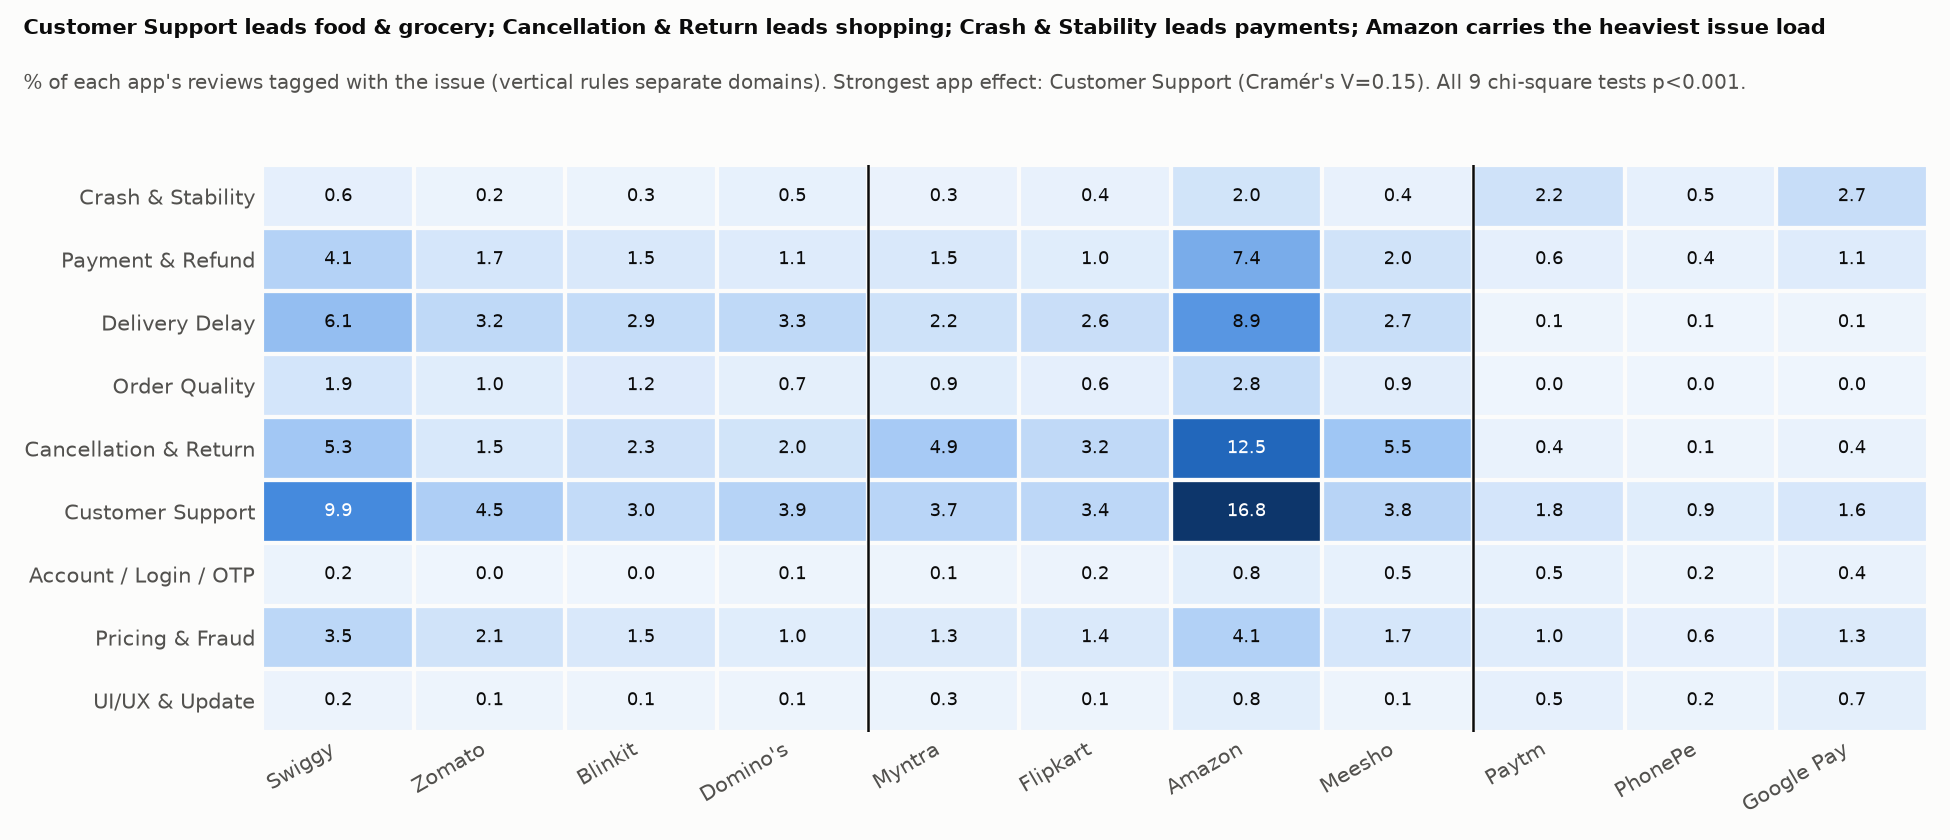

In [17]:
display(Image(REPO / "data/charts/eda/eda_06_issue_by_app.png", width=950))

**Finding 2.** Customer Support is the most common issue (4.1% of reviews) and the most damaging (1.23★). Shopping apps are led by Cancellation & Return, Food & Grocery by Customer Support and Delivery Delay; delivery problems are almost absent in Payments. Amazon has the highest rate of nearly every issue. Only 10% of reviews have any issue tag, because most reviews are only 1–3 words. **Business meaning:** one common fix will not work — each company should fix its own top problem first.

### 4.3 A collection artefact: the late-April feed gap

In [18]:
day = tagged["review_date"].dt.normalize()
periods = {"before (8-20 Apr)": ("2026-04-08", "2026-04-20"), "gap (21 Apr-5 May)": ("2026-04-21", "2026-05-05"),
           "after (6-18 May)": ("2026-05-06", "2026-05-18")}
rows = {}
for name, (a, b) in periods.items():
    w = tagged[(day >= a) & (day <= b)]
    n_days = (pd.Timestamp(b) - pd.Timestamp(a)).days + 1
    rows[("positive/day", name)] = w[w["score"] >= 4].groupby("app_name").size() / n_days
    rows[("negative/day", name)] = w[w["score"] <= 2].groupby("app_name").size() / n_days
pd.DataFrame(rows).loc[APP_NAMES].round(0)

,positive/day,negative/day,positive/day,negative/day,positive/day,negative/day
,before (8-20 Apr),before (8-20 Apr),gap (21 Apr-5 May),gap (21 Apr-5 May),after (6-18 May),after (6-18 May)
app_name,,,,,,
Swiggy,297.0,163.0,30.0,136.0,325.0,184.0
Zomato,1061.0,186.0,762.0,128.0,753.0,172.0
Blinkit,966.0,226.0,415.0,213.0,1198.0,290.0
Domino's,180.0,72.0,31.0,47.0,214.0,68.0
Myntra,443.0,53.0,355.0,40.0,439.0,40.0
Flipkart,1254.0,257.0,162.0,178.0,1557.0,309.0
Amazon,103.0,96.0,42.0,97.0,100.0,105.0
Meesho,491.0,102.0,446.0,103.0,452.0,100.0


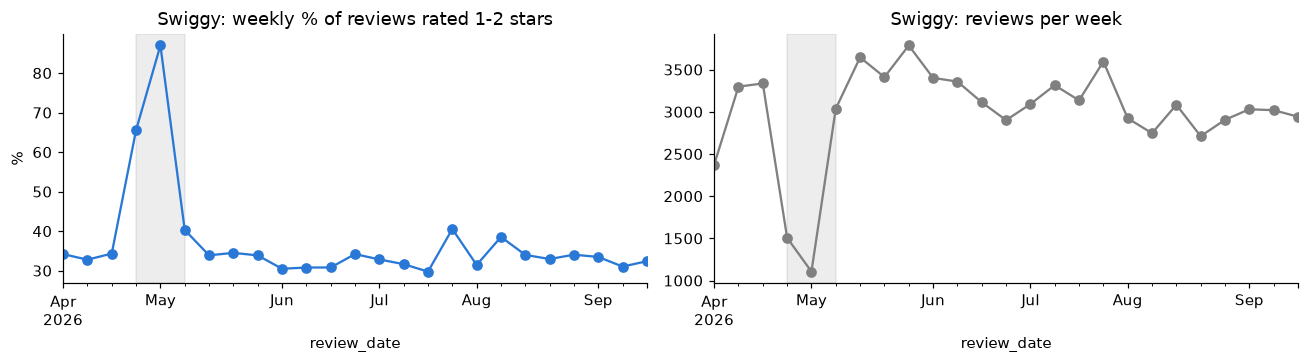

In [19]:
sw = tagged[tagged["app_name"] == "Swiggy"].set_index("review_date").sort_index()
weekly = sw.resample("W-SUN").agg({"is_problematic": "mean", "score": "size"}).rename(columns={"score": "reviews"})
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
weekly["is_problematic"].mul(100).plot(ax=ax[0], marker="o", color=APP_COLORS["Swiggy"])
ax[0].set_title("Swiggy: weekly % of reviews rated 1-2 stars"); ax[0].set_ylabel("%")
weekly["reviews"].plot(ax=ax[1], marker="o", color="grey"); ax[1].set_title("Swiggy: reviews per week")
for a in ax:
    a.axvspan(pd.Timestamp("2026-04-21"), pd.Timestamp("2026-05-06"), color="black", alpha=0.07)
plt.tight_layout(); plt.show()

**Finding 3.** From 21 April to 5 May 2026 positive reviews fall 59–90% for Swiggy, Blinkit, Domino's, Flipkart and Amazon, while negative reviews fall only 3–37%. Swiggy's "% negative" therefore jumps to ~87% for one week. Negative reviews did not rise, so this is not a wave of complaints, and a scraper failure would remove all reviews alike, so this is on the Play Store side. **Business meaning:** a "% negative" dashboard would raise a false alarm here; counting negative reviews per day is far less affected. We keep these rows, flag them, and leave them out of trend comparisons. (We also checked the "July 2026 shift" seen in our first, `MOST_RELEVANT` sample: it does not exist in the complete data — see chart 11.)

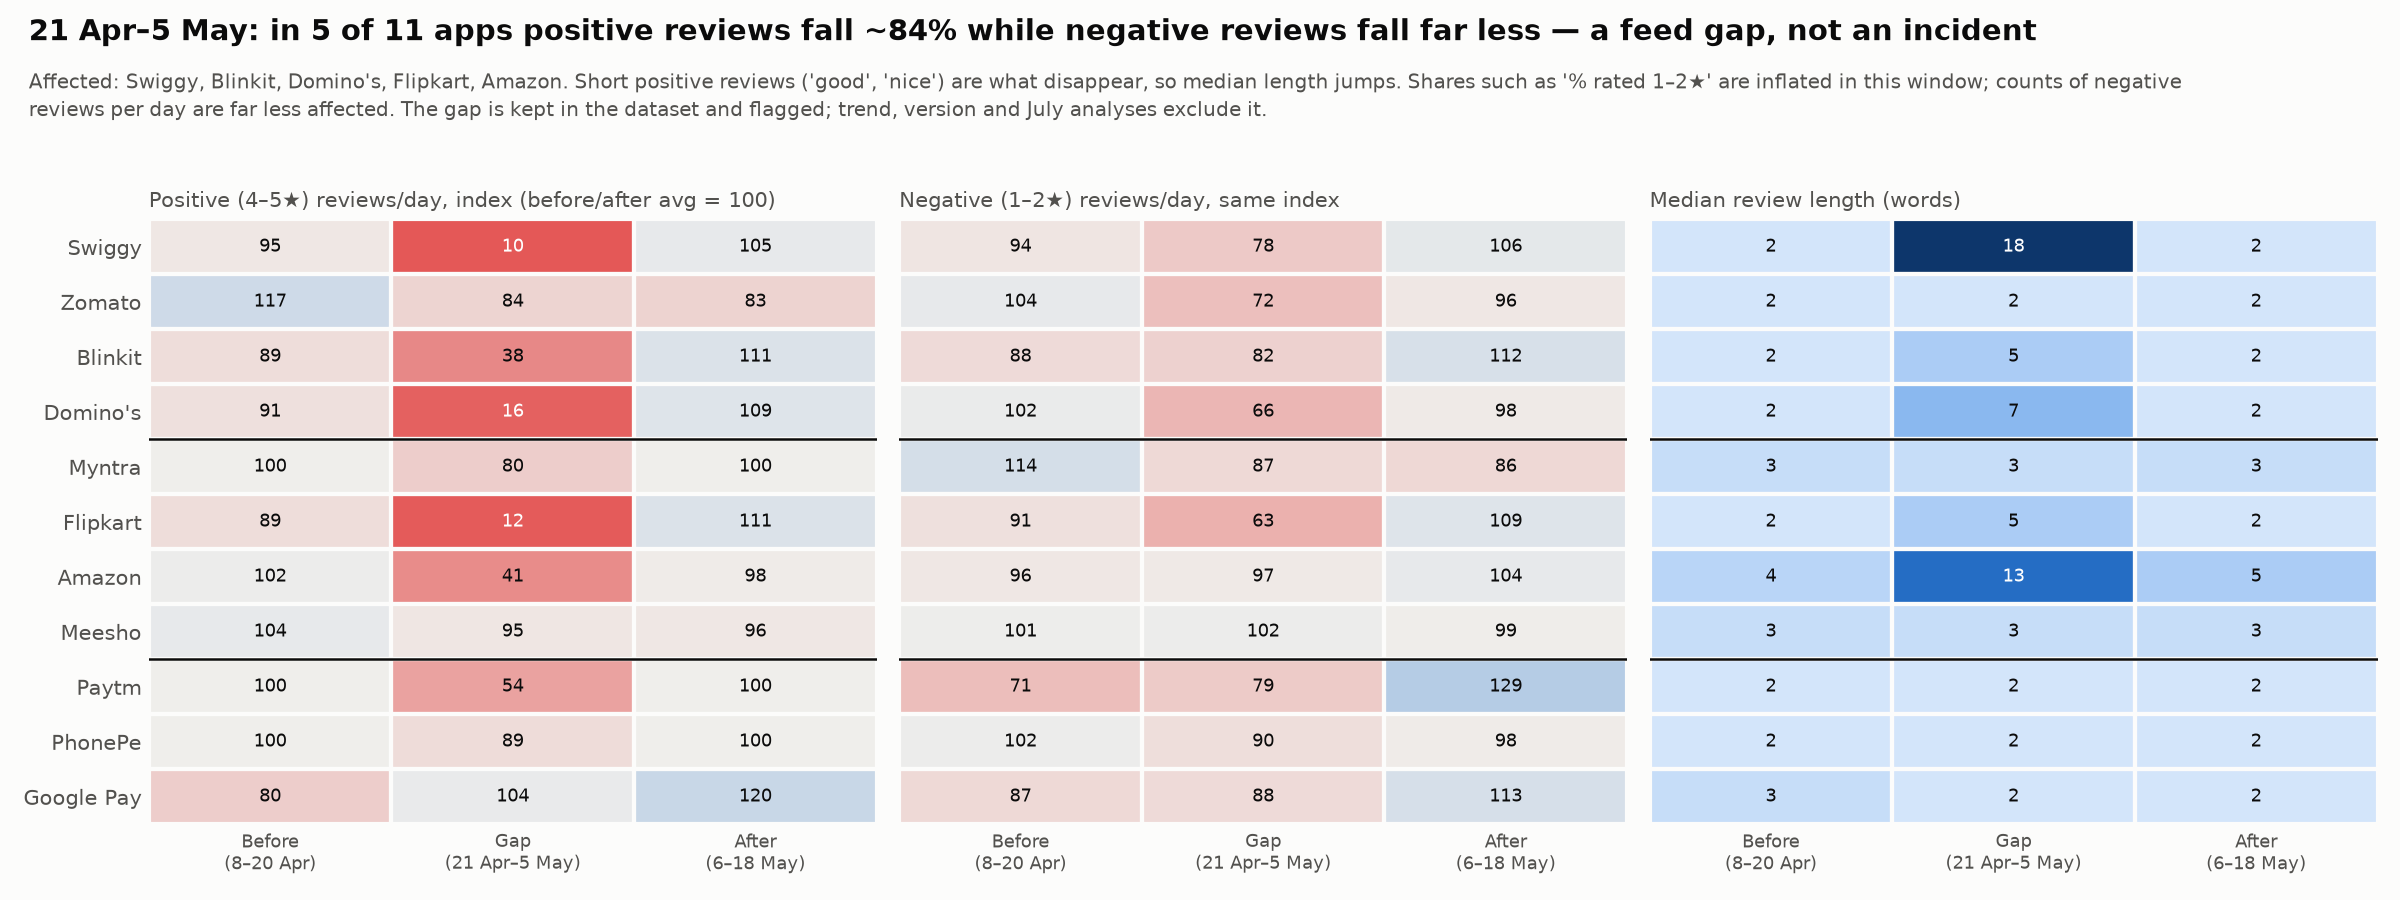

In [20]:
display(Image(REPO / "data/charts/eda/eda_15_april_gap.png", width=950))

### 4.4 Other checks

In [21]:
print("Median words by star rating:", tagged.groupby("score")["review_length"].median().to_dict())
up = tagged.groupby("score")["thumbs_up"].sum() / tagged["thumbs_up"].sum() * 100
print("Share of all upvotes by star rating (%):", up.round(1).to_dict())
print("Spearman correlations with rating:")
print(tagged[["score", "sentiment_compound", "issue_count", "review_length"]].corr(method="spearman")["score"].round(3))

Median words by star rating: {1: 14.0, 2: 4.0, 3: 2.0, 4: 2.0, 5: 2.0}
Share of all upvotes by star rating (%): {1: 59.2, 2: 5.0, 3: 4.5, 4: 12.6, 5: 18.7}
Spearman correlations with rating:
score                 1.000
sentiment_compound    0.488
issue_count          -0.496
review_length        -0.391
Name: score, dtype: float64


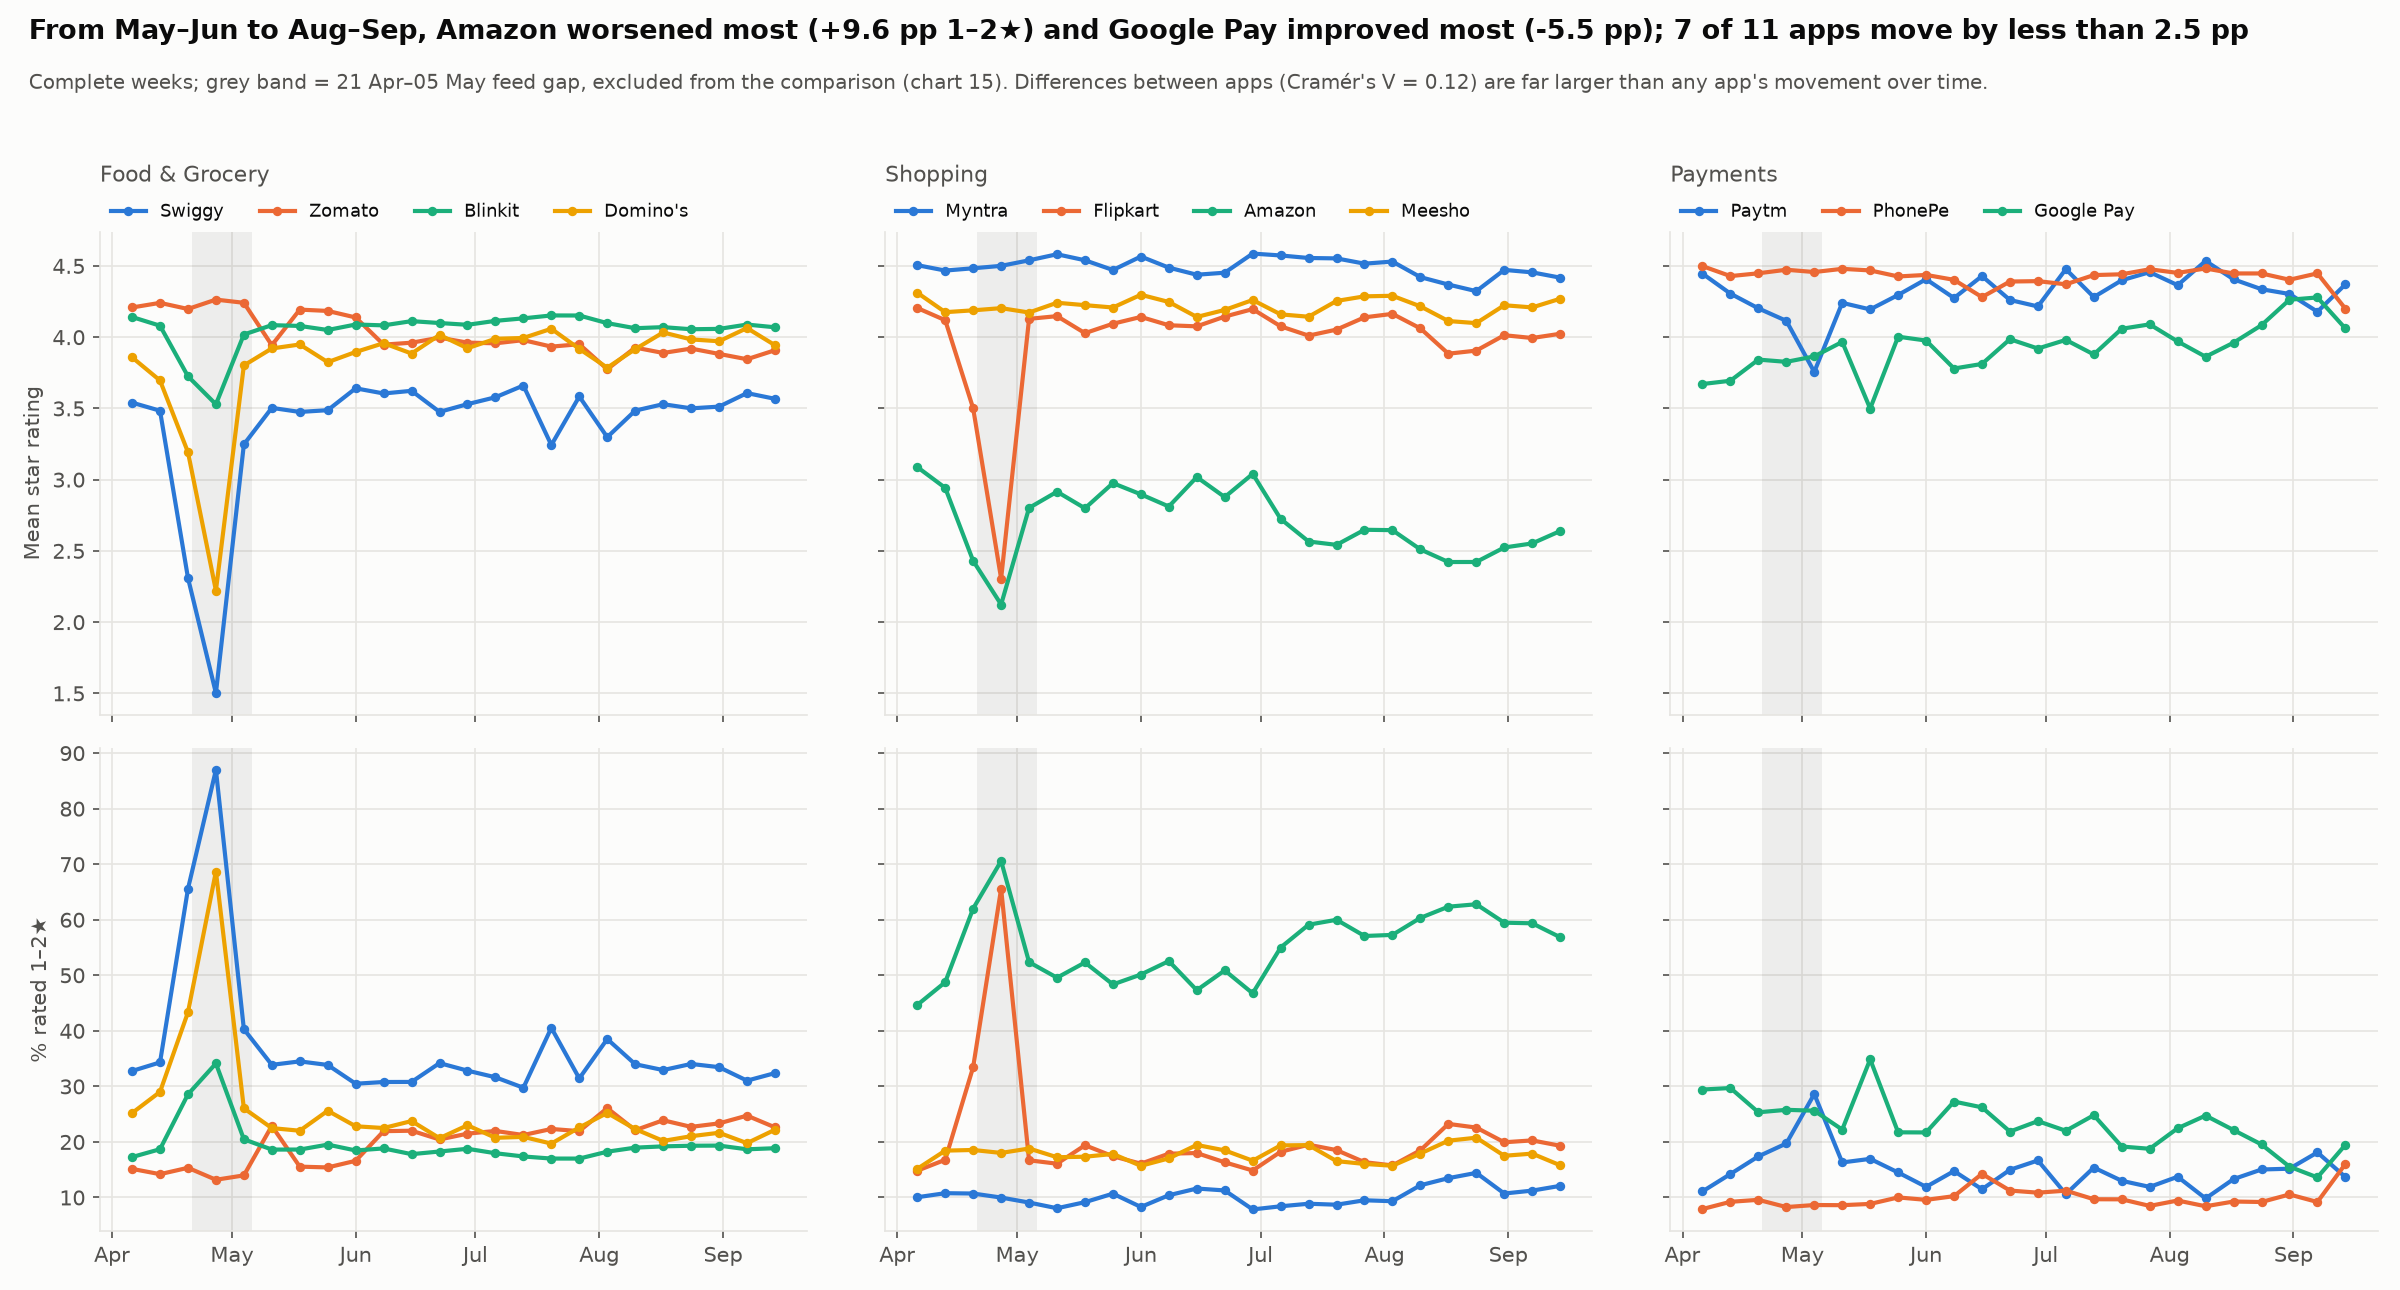

In [22]:
display(Image(REPO / "data/charts/eda/eda_10_weekly_trend.png", width=950))

## 5. Feature engineering and dimensionality reduction

* **Text:** TF-IDF (20,000 terms, single words and 2-word phrases, sublinear term frequency, min_df 3, max_df 0.95, **no stop-word list** so negations such as "not good" are kept), then **Truncated SVD** to 200 components.
* **Structural (15):** 9 issue flags, 4 VADER scores, `review_length`, `thumbs_up` — scaled with `StandardScaler`.
* **Total:** 215 features. Same settings as `scripts/05_feature_engineering.py`.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

structural_cols = [f"issue_{i}" for i in ISSUES] + ["sentiment_neg", "sentiment_neu", "sentiment_pos", "sentiment_compound",
                                                     "review_length", "thumbs_up"]
y = tagged["is_problematic"].to_numpy()
print(f"Target: {y.sum():,} problematic ({y.mean()*100:.1f}%), {(1-y).sum():,} not problematic")

t0 = time.time()
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.95, sublinear_tf=True, dtype=np.float32)
X_tfidf = tfidf.fit_transform(tagged["content"].fillna("").astype(str))
svd = TruncatedSVD(n_components=200, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
X_struct = StandardScaler().fit_transform(tagged[structural_cols].fillna(0).astype(float))
X = np.hstack([X_svd, X_struct]).astype(np.float32)
feature_names = [f"SVD_{i}" for i in range(200)] + structural_cols
print(f"TF-IDF {X_tfidf.shape} -> SVD {X_svd.shape} (keeps {svd.explained_variance_ratio_.sum()*100:.1f}% of variance)")
print(f"Final feature matrix: {X.shape}   ({time.time()-t0:.0f}s)")

Target: 221,581 problematic (19.5%), 916,406 not problematic


TF-IDF (1137987, 20000) -> SVD (1137987, 200) (keeps 62.7% of variance)
Final feature matrix: (1137987, 215)   (124s)


In [24]:
terms = np.array(tfidf.get_feature_names_out())
for k in range(4):
    comp = svd.components_[k]
    print(f"SVD_{k}: + {', '.join(terms[np.argsort(-comp)[:6]])}")

SVD_0: + good, very good, very, good service, good app, service
SVD_1: + nice, very nice, very, nice app, app, very good
SVD_2: + very good, very, very nice, app, good app, service
SVD_3: + best, super, app, best app, good app, nice app


**Justification.** A 1.1-million × 20,000 sparse matrix is slow and noisy for a Random Forest; SVD gives a compact dense representation (100× fewer text columns). Issue flags and sentiment add meaning single words miss; `review_length` is kept explicitly because complaints are much longer than praise (14 vs 2 words median).

**Effect.** 20,000 → 200 text columns while keeping ~63% of the TF-IDF variance (most reviews use a small vocabulary).

## 6. Predictive model development

* **Task:** binary classification of `is_problematic`.
* **Models:** Logistic Regression (simple, interpretable baseline) and Random Forest (non-linear interactions, feature importance); both with `class_weight="balanced"` because only 19.5% of reviews are problematic.
* **Split:** stratified 80/20, `random_state=42`.
* **Random Forest settings:** 150 trees, each on a 30% bootstrap sample, `min_samples_leaf=100` — keeps the model small (≈10 MB) on 910k training rows. No grid search.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, precision_recall_curve, roc_curve)

idx_train, idx_test = train_test_split(np.arange(len(y)), test_size=0.20, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = X[idx_train], X[idx_test], y[idx_train], y[idx_test]
print(f"Train {len(y_train):,} / Test {len(y_test):,}; problematic share train {y_train.mean():.3f}, test {y_test.mean():.3f}")

def make_models():
    return {"Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=150, max_samples=0.3, min_samples_leaf=100,
                                                    class_weight="balanced", random_state=42, n_jobs=-1)}

def scores(y_true, y_pred, y_prob):
    return {"accuracy": accuracy_score(y_true, y_pred), "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred), "f1": f1_score(y_true, y_pred),
            "roc_auc": roc_auc_score(y_true, y_prob), "pr_auc": average_precision_score(y_true, y_prob)}

models, probs, preds, results = make_models(), {}, {}, {}
results["Majority-class baseline"] = scores(y_test, np.zeros_like(y_test), np.zeros(len(y_test)))
for name, m in models.items():
    t0 = time.time(); m.fit(X_train, y_train)
    probs[name] = m.predict_proba(X_test)[:, 1]; preds[name] = m.predict(X_test)
    results[name] = scores(y_test, preds[name], probs[name])
    print(f"{name}: trained in {time.time()-t0:.0f}s")

Train 910,389 / Test 227,598; problematic share train 0.195, test 0.195


Logistic Regression: trained in 26s


Random Forest: trained in 61s


## 7. Model evaluation and result interpretation

Classification metrics: accuracy, precision, recall, F1, confusion matrix, plus ROC-AUC and PR-AUC. (R², MAE, MSE and RMSE are regression metrics and do not apply to this classifier.)

In [26]:
res = pd.DataFrame(results).T.round(4)
res

,accuracy,precision,recall,f1,roc_auc,pr_auc
Majority-class baseline,0.8053,0.0000,0.0000,0.0000,0.5000,0.1947
Logistic Regression,0.9216,0.7672,0.8579,0.8100,0.9400,0.8710
Random Forest,0.9143,0.7372,0.8701,0.7982,0.9411,0.8735


In [27]:
cms = {n: confusion_matrix(y_test, p) for n, p in preds.items()}
pd.DataFrame({n: {"true negative": c[0, 0], "false positive": c[0, 1], "false negative": c[1, 0], "true positive": c[1, 1]}
              for n, c in cms.items()}).T

,true negative,false positive,false negative,true positive
Logistic Regression,171744,11538,6297,38019
Random Forest,169539,13743,5756,38560


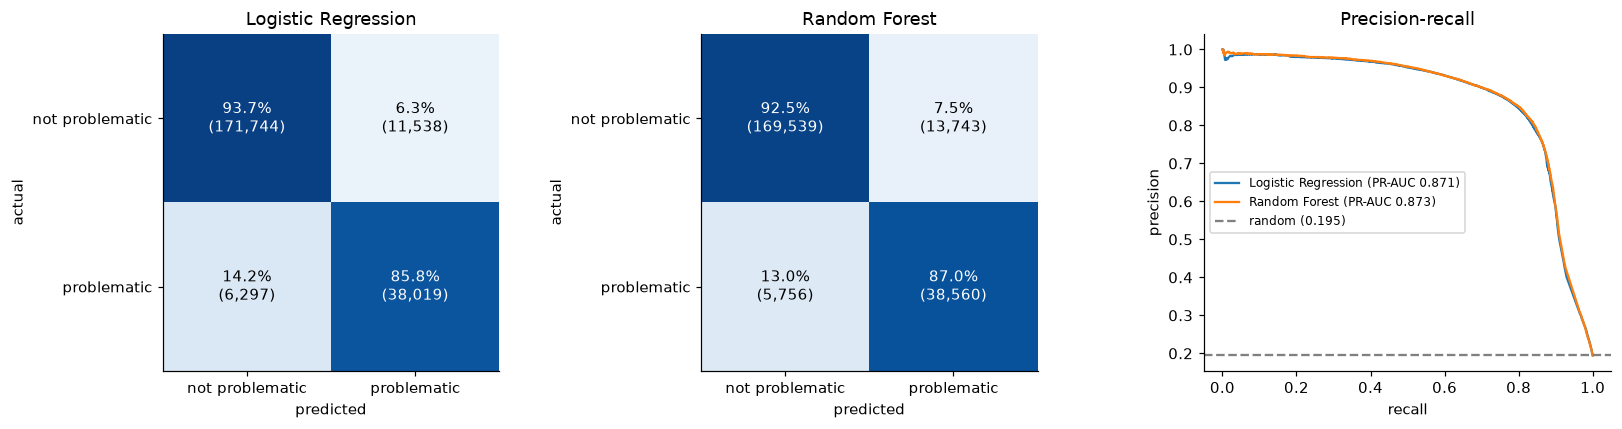

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for k, (name, c) in enumerate(cms.items()):
    cn = c / c.sum(axis=1, keepdims=True)
    ax[k].imshow(cn, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax[k].text(j, i, f"{cn[i, j]:.1%}\n({c[i, j]:,})", ha="center", va="center", color="white" if cn[i, j] > .5 else "black")
    ax[k].set_xticks([0, 1], ["not problematic", "problematic"]); ax[k].set_yticks([0, 1], ["not problematic", "problematic"])
    ax[k].set_xlabel("predicted"); ax[k].set_ylabel("actual"); ax[k].set_title(name)
for name in probs:
    p, r, _ = precision_recall_curve(y_test, probs[name]); ax[2].plot(r, p, label=f"{name} (PR-AUC {results[name]['pr_auc']:.3f})")
ax[2].axhline(y_test.mean(), ls="--", color="grey", label=f"random ({y_test.mean():.3f})")
ax[2].set_xlabel("recall"); ax[2].set_ylabel("precision"); ax[2].set_title("Precision-recall"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 7.1 Where does the model work best? (Random Forest, by domain and app)

In [29]:
test = tagged.iloc[idx_test][["app_name", "domain"]].reset_index(drop=True)
test["y"], test["pred"], test["prob"] = y_test, preds["Random Forest"], probs["Random Forest"]
def grp(g):
    return pd.Series({"test reviews": len(g), "% problematic": g["y"].mean() * 100,
                      "precision": precision_score(g["y"], g["pred"]), "recall": recall_score(g["y"], g["pred"]),
                      "pr_auc": average_precision_score(g["y"], g["prob"])})
pd.concat([test.groupby("domain").apply(grp, include_groups=False), test.groupby("app_name").apply(grp, include_groups=False)]).round(3)

,test reviews,% problematic,precision,recall,pr_auc
Food & Grocery,99491.0,21.745,0.738,0.905,0.895
Payments,30747.0,12.860,0.626,0.805,0.750
Shopping,97360.0,19.236,0.764,0.843,0.869
Amazon,6705.0,54.825,0.908,0.961,0.969
Blinkit,45707.0,18.953,0.664,0.906,0.865
Domino's,8568.0,23.938,0.784,0.889,0.898
Flipkart,53192.0,18.117,0.771,0.742,0.800
Google Pay,4049.0,23.388,0.685,0.855,0.813
Meesho,20509.0,17.826,0.693,0.942,0.909
Myntra,16954.0,10.375,0.654,0.949,0.926


### 7.2 Does it work on future weeks? (train April–August, test 1–20 September)

In [30]:
past = (tagged["review_date"] < "2026-09-01").to_numpy()
oot = {}
for name, m in make_models().items():
    m.fit(X[past], y[past]); prob = m.predict_proba(X[~past])[:, 1]
    oot[name] = scores(y[~past], (prob >= 0.5).astype(int), prob)
print(f"train {past.sum():,} reviews (Apr-Aug), test {(~past).sum():,} reviews (1-20 Sep)")
pd.DataFrame(oot).T.round(4)

train 1,008,932 reviews (Apr-Aug), test 129,055 reviews (1-20 Sep)


,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.9124,0.7481,0.8493,0.7955,0.9376,0.8617
Random Forest,0.9053,0.7207,0.8617,0.7849,0.9392,0.8660


### 7.3 What drives the predictions?

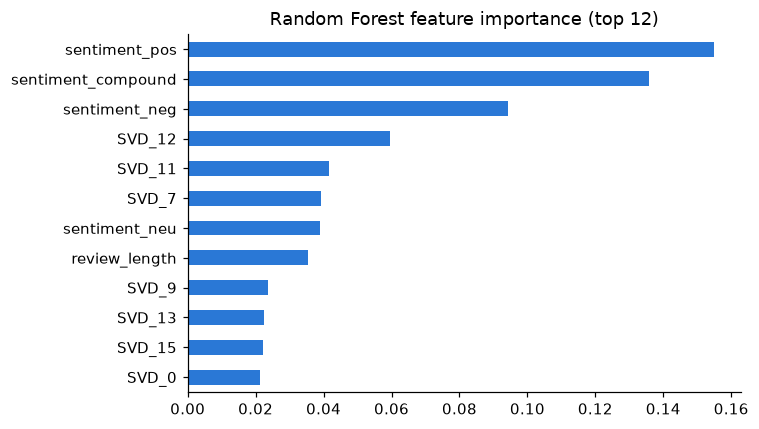

,sentiment_pos,sentiment_compound,sentiment_neg,SVD_12,SVD_11,SVD_7,sentiment_neu,review_length
importance,0.155,0.136,0.094,0.059,0.042,0.039,0.039,0.035


In [31]:
imp = pd.Series(models["Random Forest"].feature_importances_, index=feature_names).sort_values(ascending=False)
ax = imp.head(12)[::-1].plot.barh(figsize=(7, 4), color="#2a78d6", title="Random Forest feature importance (top 12)")
plt.tight_layout(); plt.show()
imp.head(8).round(3).to_frame("importance").T

### 7.4 Interpretation and business findings

**Strengths**
* Only 19.5% of reviews are problematic, so a model that never flags anything already scores 80.5% accuracy but finds **no** complaints. Accuracy is therefore not the headline — PR-AUC is: **0.87 for both models vs 0.195 for random guessing.** Both are more than 91% accurate.
* The two models are close: Logistic Regression is more precise at the default threshold (precision 0.77 vs 0.74, about 16% fewer false alarms), while the Random Forest finds slightly more complaints (recall 0.87 vs 0.86) and has the slightly higher PR-AUC.
* Training on April–August and testing on 1–20 September costs less than 0.01 PR-AUC, so the models generalise to future weeks.

**Limitations**
* The target is the star rating: the model predicts "low rating", not a confirmed failure. Some users give 1★ with praise text ("nice product"), and some 5★ with complaints.
* Most reviews are 1–3 words, so for them the model mostly reads sentiment; payment apps (rarer, shorter complaints) are the hardest domain.
* TF-IDF/SVD/scaler are fitted before the split (they do not use the target); no hyper-parameter search.

**Initial business findings**
1. Triage reviews automatically: the Random Forest catches 87% of complaints with about 3 in 4 flags correct; Logistic Regression catches 86% with about 77% of flags correct. Choose by whether missed complaints or reviewer time cost more.
2. Each app should start with its own top issue: Customer Support and delivery for food apps, returns and support for shopping apps (Amazon worst on almost everything), support and stability for payment apps.
3. Monitor complaints as **counts per day**, not "% negative": the late-April Play Store gap would otherwise trigger a false alarm.